In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import copy

In [2]:
df = pd.read_csv("../data/indoorAir2.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s') 
df = df.sort_values(by='timestamp')

print(df.shape)
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# # Hour cyclic features
# df["hour"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60

# df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
# df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# # Day of week cyclic features
# df["dayofweek"] = df["timestamp"].dt.dayofweek

# df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
# df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# # Weekend feature
# df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# feature_df = df[
#     [
#         "ens160_aqi",
#         "ens160_tvoc",
#         "bme688_gas_resistance",
#         "bme688_pressure",
#         "scd41_temperature",
#         "scd41_humidity",
#         "timestamp",
#         "scd41_co2",
#         "hour_sin",
#         "hour_cos",
#         "dayofweek_sin",
#         "dayofweek_cos",
#         "is_weekend",
#         "station_id",
#     ]
# ].copy()

df = df[df["station_id"] != 6].copy()

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "station_id",
    ]
].copy()
print(feature_df.shape)
feature_df.head()

(1924649, 9)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,timestamp,scd41_co2,station_id
0,1,32,NaN,NaN,22.951857,36.897277,2024-11-13 16:57:56,488.0,1
1,1,30,NaN,NaN,22.335011,38.185119,2024-11-13 16:58:57,485.0,1
2,1,43,NaN,NaN,22.353704,38.400268,2024-11-13 16:59:59,477.0,1
3,1,26,NaN,NaN,22.417792,38.269042,2024-11-13 17:01:03,474.0,1
4,1,31,NaN,NaN,22.556649,37.971496,2024-11-13 17:02:05,473.0,1


In [4]:
resample_freq = "15min"   # or "5min", etc.

value_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

feature_df = (
    feature_df
    .sort_values(["station_id", "timestamp"])
    .set_index("timestamp")
    .groupby("station_id")[value_cols]
    .resample(resample_freq)
    .mean()
    .reset_index()
)

feature_df[value_cols] = (
    feature_df
    .groupby("station_id")[value_cols]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186889, 9)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408


In [5]:
print(feature_df.shape)
# Sort before merge_asof
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

# Create target lookup dataframe
target_df = feature_df[["station_id", "timestamp", "scd41_co2"]].copy()

target_df = target_df.rename(
    columns={
        "timestamp": "actual_target_timestamp",
        "scd41_co2": "target_co2_15min"
    }
)

# Required future timestamp
feature_df["target_timestamp"] = feature_df["timestamp"] + pd.Timedelta(minutes=15)

# Sort for merge_asof
feature_df = feature_df.sort_values(["target_timestamp", "station_id"]).reset_index(drop=True)
target_df = target_df.sort_values(["actual_target_timestamp", "station_id"]).reset_index(drop=True)

# Find nearest CO2 value around timestamp + 15 min
feature_df = pd.merge_asof(
    feature_df,
    target_df,
    left_on="target_timestamp",
    right_on="actual_target_timestamp",
    by="station_id",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=2)
)

# Check actual difference from exact 15 min
feature_df["target_diff_seconds"] = (
    feature_df["actual_target_timestamp"] - feature_df["target_timestamp"]
).abs().dt.total_seconds()

# Remove rows without valid 15-min target
feature_df = feature_df.dropna(subset=["target_co2_15min"]).reset_index(drop=True)

feature_df = feature_df.drop(
    columns=[
        "target_timestamp",
        "actual_target_timestamp",
        "target_diff_seconds"
    ]
)

print(feature_df.shape)
feature_df.head()

(186889, 9)
(186884, 10)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,target_co2_15min
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,472.285714
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,471.997279
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,471.708844
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,471.420408
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,471.131973


In [6]:
cols_to_fill = ["bme688_gas_resistance", "bme688_pressure"]

#feature_df = feature_df.sort_values("station_id").reset_index(drop=True)
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .transform(lambda x: x.interpolate(method="linear"))
)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .ffill()
    .bfill()
)

print(feature_df.shape)
feature_df.head()

(186884, 10)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,target_co2_15min
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,472.285714
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,471.997279
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,471.708844
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,471.420408
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,471.131973


In [7]:
numeric_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "target_co2_15min"
]

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    feature_df[col] = feature_df[col].clip(lower=lower, upper=upper)

print(feature_df.shape)
feature_df.head()

(186884, 10)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,target_co2_15min
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,472.285714
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,471.997279
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,471.708844
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,471.420408
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,471.131973


In [8]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (outlier_count / len(feature_df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   
target_co2_15min       2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2                          0.0  
target_co2_15min                   0.0  


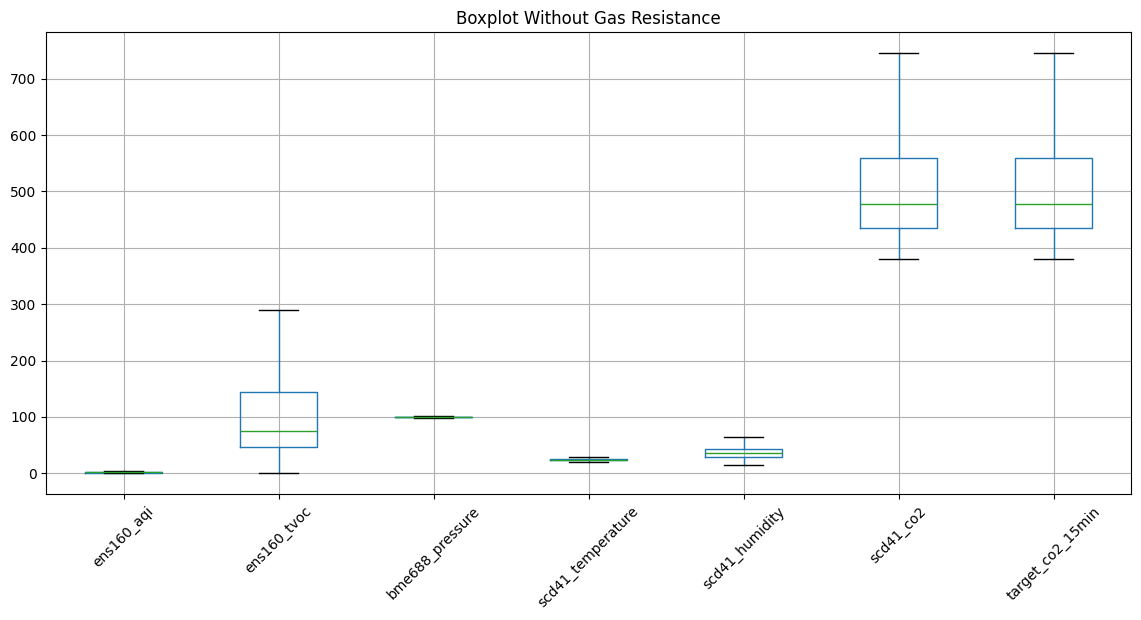

In [9]:
plot_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "target_co2_15min"
]

feature_df[plot_cols].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot Without Gas Resistance")
plt.show()

In [10]:
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

def split_station_data(station_data):
    station_data = station_data.sort_values("timestamp")
    n_rows = len(station_data)
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )

train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_data(station_data)
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

train_df = pd.concat(train_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)

total_rows = len(feature_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train percentage:", len(train_df) / total_rows * 100)
print("Val percentage:", len(val_df) / total_rows * 100)
print("Test percentage:", len(test_df) / total_rows * 100)

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("val"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nRows per station:")
print(split_counts)

Train shape: (130816, 10)
Val shape: (28031, 10)
Test shape: (28037, 10)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381


In [11]:
target_col = "target_co2_15min"

"""feature_cols = [
    col for col in feature_df.columns
    if col != target_col
]"""
feature_cols = [
    col for col in feature_df.columns
    if col not in [target_col, "timestamp"]
]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
val_df_scaled[feature_cols] = x_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])
val_df_scaled[[target_col]] = y_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df[[target_col]])

print("Scaled X min/max:", train_df_scaled[feature_cols].min().min(), train_df_scaled[feature_cols].max().max())
print("Scaled y min/max:", train_df_scaled[target_col].min(), train_df_scaled[target_col].max())

Scaled X min/max: 0.0 1.0000000000000002
Scaled y min/max: 0.0 1.0000000000000002


In [12]:
input_size = 60

def create_windows(data, feature_cols, target_col="target_co2_15min"):
    X_windows = []
    y_windows = []

    data = data.sort_values(["station_id", "timestamp"])

    for station_id, station_data in data.groupby("station_id"):
        X = station_data[feature_cols].values.astype("float32")
        y = station_data[target_col].values.astype("float32")

        for i in range(input_size, len(station_data)):
            # X_windows.append(X[i - input_size:i])
            # y_windows.append(y[i])
            X_windows.append(X[i - input_size:i])
            # Target belongs to the last timestamp inside the input window.
            # Since target_col is already 15-min-ahead CO2, use i - 1.
            y_windows.append(y[i - 1])

    return np.array(X_windows, dtype="float32"), np.array(y_windows, dtype="float32")


X_train, y_train = create_windows(train_df_scaled, feature_cols, target_col)
X_val, y_val = create_windows(val_df_scaled, feature_cols, target_col)
X_test, y_test = create_windows(test_df_scaled, feature_cols, target_col)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (130516, 60, 8) y_train: (130516,)
X_val: (27731, 60, 8) y_val: (27731,)
X_test: (27737, 60, 8) y_test: (27737,)


In [13]:
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2040
Val batches: 434
Test batches: 434


In [14]:
class NBeatsBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, theta_dim, num_layers=4):
        super(NBeatsBlock, self).__init__()

        layers = [
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        ]

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        self.fc = nn.Sequential(*layers)
        self.backcast_layer = nn.Linear(hidden_dim, input_dim)
        self.forecast_layer = nn.Linear(hidden_dim, theta_dim)

    def forward(self, x):
        h = self.fc(x)

        backcast = self.backcast_layer(h)
        forecast = self.forecast_layer(h)

        return backcast, forecast

In [15]:
class NBeats(nn.Module):
    def __init__(
        self,
        input_size,
        num_features,
        hidden_dim=256,
        num_blocks=2,
        num_layers=3,
        horizon=1
    ):
        super(NBeats, self).__init__()

        self.input_dim = input_size * num_features
        self.horizon = horizon

        self.blocks = nn.ModuleList([
            NBeatsBlock(
                input_dim=self.input_dim,
                hidden_dim=hidden_dim,
                theta_dim=horizon,
                num_layers=num_layers
            )
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = x.reshape(x.size(0), -1)

        residual = x
        forecast = torch.zeros(
            x.size(0),
            self.horizon,
            device=x.device
        )

        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast

        return forecast

In [16]:
num_features = X_train.shape[2]
horizon = 1

model = NBeats(
    input_size=input_size,
    num_features=num_features,
    hidden_dim=256,
    num_blocks=2,
    num_layers=3,
    horizon=horizon
)

print(model)

NBeats(
  (blocks): ModuleList(
    (0-1): 2 x NBeatsBlock(
      (fc): Sequential(
        (0): Linear(in_features=480, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): ReLU()
      )
      (backcast_layer): Linear(in_features=256, out_features=480, bias=True)
      (forecast_layer): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)


In [17]:
import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [18]:
X_batch, y_batch = next(iter(train_loader))

y_pred = model(X_batch)

print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("y_pred shape:", y_pred.shape)

print("y_batch min/max:", y_batch.min().item(), y_batch.max().item())
print("y_pred min/max:", y_pred.min().item(), y_pred.max().item())

loss = criterion(y_pred, y_batch)

print("Batch loss:", loss.item())

X_batch shape: torch.Size([64, 60, 8])
y_batch shape: torch.Size([64, 1])
y_pred shape: torch.Size([64, 1])
y_batch min/max: 0.0626816377043724 1.0
y_pred min/max: -0.12843632698059082 -0.09520866721868515
Batch loss: 0.33161136507987976


In [19]:
num_epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.6f} "
        f"Val Loss: {avg_val_loss:.6f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

print("Best Val Loss:", best_val_loss)

Epoch [1/30] Train Loss: 0.003771 Val Loss: 0.001644
Epoch [2/30] Train Loss: 0.001636 Val Loss: 0.001176
Epoch [3/30] Train Loss: 0.001492 Val Loss: 0.001325
Epoch [4/30] Train Loss: 0.001432 Val Loss: 0.001370
Epoch [5/30] Train Loss: 0.001366 Val Loss: 0.001311
Epoch [6/30] Train Loss: 0.001367 Val Loss: 0.001336
Epoch [7/30] Train Loss: 0.001304 Val Loss: 0.001134
Epoch [8/30] Train Loss: 0.001293 Val Loss: 0.001129
Epoch [9/30] Train Loss: 0.001260 Val Loss: 0.001208
Epoch [10/30] Train Loss: 0.001244 Val Loss: 0.001255
Epoch [11/30] Train Loss: 0.001233 Val Loss: 0.001881
Epoch [12/30] Train Loss: 0.001235 Val Loss: 0.001122
Epoch [13/30] Train Loss: 0.001229 Val Loss: 0.001204
Epoch [14/30] Train Loss: 0.001208 Val Loss: 0.001512
Epoch [15/30] Train Loss: 0.001211 Val Loss: 0.000990
Epoch [16/30] Train Loss: 0.001195 Val Loss: 0.001264
Epoch [17/30] Train Loss: 0.001192 Val Loss: 0.001498
Epoch [18/30] Train Loss: 0.001195 Val Loss: 0.001240
Epoch [19/30] Train Loss: 0.001171 Va

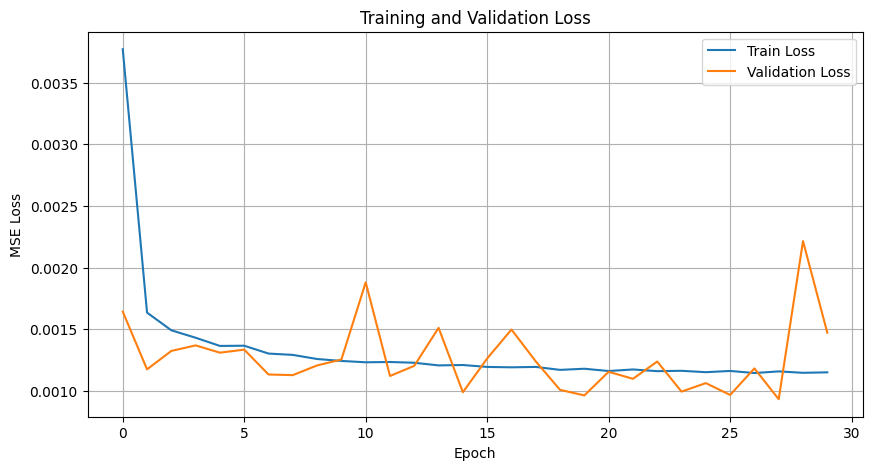

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
model.eval()

test_predictions = []
test_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)

        test_predictions.append(y_pred.numpy())
        test_actuals.append(y_batch.numpy())

test_predictions = np.vstack(test_predictions)
test_actuals = np.vstack(test_actuals)

In [22]:
# Metrics WITHOUT inverse scaling: scaled 0-1 target space
mae_scaled = mean_absolute_error(test_actuals, test_predictions)
mse_scaled = mean_squared_error(test_actuals, test_predictions)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(test_actuals, test_predictions)

print("Metrics WITHOUT inverse scaling")
print("MAE:", mae_scaled)
print("MSE:", mse_scaled)
print("RMSE:", rmse_scaled)
print("R2:", r2_scaled)

Metrics WITHOUT inverse scaling
MAE: 0.00897207297384739
MSE: 0.00042943606968037784
RMSE: 0.020722839324773472
R2: 0.9952260851860046


In [23]:
# Metrics WITH inverse scaling: original CO2 ppm space
test_predictions_original = y_scaler.inverse_transform(test_predictions)
test_actuals_original = y_scaler.inverse_transform(test_actuals)

print("Predictions shape:", test_predictions_original.shape)
print("Actuals shape:", test_actuals_original.shape)

Predictions shape: (27737, 1)
Actuals shape: (27737, 1)


In [24]:
mae = mean_absolute_error(test_actuals_original, test_predictions_original)
mse = mean_squared_error(test_actuals_original, test_predictions_original)
rmse = np.sqrt(mse)
r2 = r2_score(test_actuals_original, test_predictions_original)

print("Metrics WITH inverse scaling")
print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R2:", r2)

Metrics WITH inverse scaling
Test MAE: 3.27783465385437
Test MSE: 57.317657470703125
Test RMSE: 7.570842586575362
Test R2: 0.9952260851860046


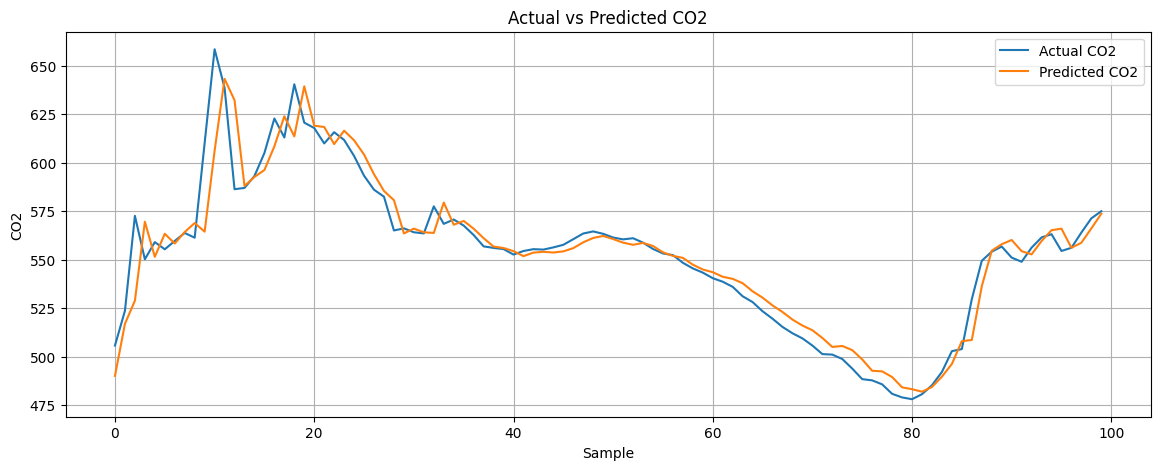

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(test_actuals_original[:100], label="Actual CO2")
plt.plot(test_predictions_original[:100], label="Predicted CO2")
plt.xlabel("Sample")
plt.ylabel("CO2")
plt.title("Actual vs Predicted CO2")
plt.legend()
plt.grid(True)
plt.show()

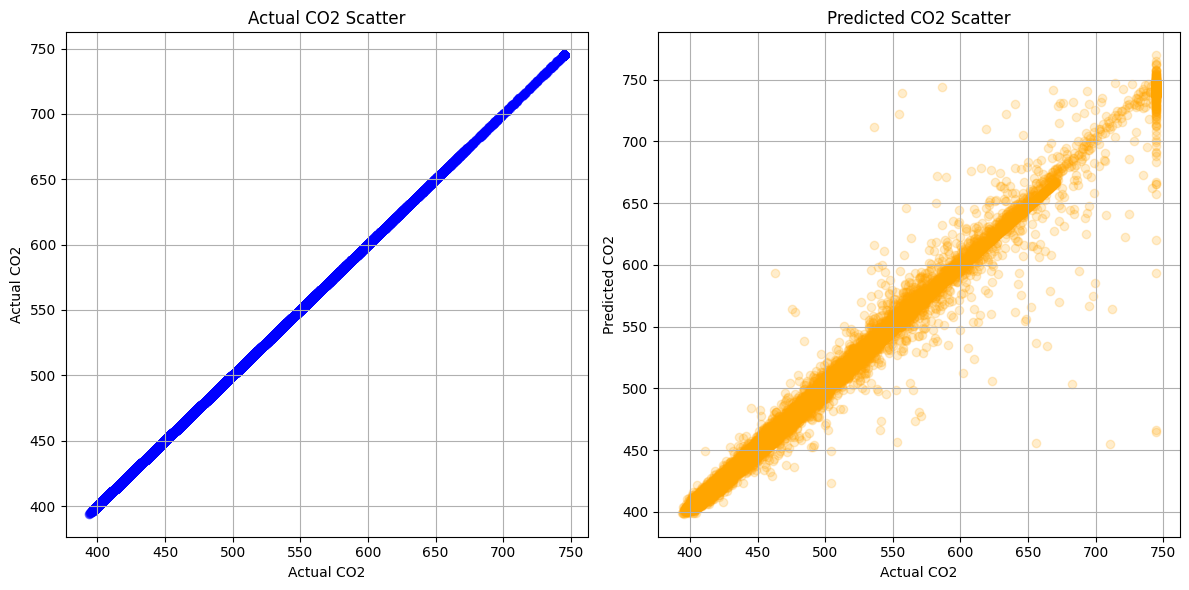

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Actual CO2 graph
ax[0].scatter(
    test_actuals_original,
    test_actuals_original,
    color='blue',
    alpha=0.5
)
ax[0].set_xlabel("Actual CO2")
ax[0].set_ylabel("Actual CO2")
ax[0].set_title("Actual CO2 Scatter")
ax[0].grid(True)

# Predicted CO2 graph
ax[1].scatter(
    test_actuals_original,
    test_predictions_original,
    color='orange',
    alpha=0.2
)
ax[1].set_xlabel("Actual CO2")
ax[1].set_ylabel("Predicted CO2")
ax[1].set_title("Predicted CO2 Scatter")
ax[1].grid(True)

plt.tight_layout()
plt.show()